# **NIALM SD MACHINE LEARNING**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np 
import datetime as dt
import sklearn
from scipy import stats
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Import necessary modules
from sklearn import preprocessing
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import accuracy_score


Read csv File

In [2]:
# Counts the number of columns in the file
with open('NIALM_ML.csv') as x:
    ncols = len(x.readline().split(',')) 

# Reads the csv file, skipping the first 4 columns
df = pd.read_csv('NIALM_ML.csv', usecols=range(4, ncols)) 

# Prints the shape of the dataframe
print(df.shape) 

# Prints the statistics of the dataframe
#transpose() is used to make the output more readable
#“1” represents the status ON while “0” represents status OFF
#Looking at the summary for the 'STATUS' variable, we observe that the mean value is 0.5, which means that around 50 percent of the observations in the dataset LED is on. Therefore, the baseline accuracy is 50 percent and our neural network model should definitely beat this baseline benchmark.
df.describe().transpose() 

(3200, 11)


,count,mean,std,min,25%,50%,75%,max
VOLTAGE,3200.0,242.866286,1.592622,239.100,242.800,243.4000,244.000000,244.9000
CURRENT,3200.0,2.470854,2.255211,0.038,0.129,0.9880,4.564600,6.4220
POWER,3200.0,573.663950,529.312468,0.000,22.500,233.3950,1064.839225,1526.5999
FREQUENCY,3200.0,49.976289,0.035284,49.900,49.960,50.0000,50.000000,50.0000
PF,3200.0,0.817945,0.259583,0.000,0.750,0.9530,0.960000,1.0000
SDVOLTAGE,3200.0,0.014126,0.023335,0.000,0.000,0.0000,0.030000,0.1886
SDCURRENT,3200.0,0.014785,0.060803,0.000,0.000,0.0000,0.001825,0.8382
SDPOWER,3200.0,3.610527,14.799670,0.000,0.000,0.0299,0.396150,172.6714
SDFREQUENCY,3200.0,0.012440,0.020235,0.000,0.000,0.0000,0.030000,0.0498
SDPF,3200.0,0.002777,0.015067,0.000,0.000,0.0000,0.000000,0.3076


Creating Arrays for the Features and the Response Variable

In [3]:
# 'STATE' is the target column
target_column = ['STATE'] 

# All columns are features except 'STATUS'
feature_column = list(set(list(df.columns))-set(target_column))

# Normalize the features
df[feature_column] = df[feature_column]/df[feature_column].max() 

# Show the summary of the data
df.describe().transpose() 

,count,mean,std,min,25%,50%,75%,max
VOLTAGE,3200.0,0.991696,0.006503,0.976317,0.991425,0.993875,0.996325,1.0
CURRENT,3200.0,0.384748,0.351170,0.005917,0.020087,0.153846,0.710775,1.0
POWER,3200.0,0.375779,0.346726,0.000000,0.014739,0.152886,0.697523,1.0
FREQUENCY,3200.0,0.999526,0.000706,0.998000,0.999200,1.000000,1.000000,1.0
PF,3200.0,0.817945,0.259583,0.000000,0.750000,0.953000,0.960000,1.0
SDVOLTAGE,3200.0,0.074901,0.123727,0.000000,0.000000,0.000000,0.159067,1.0
SDCURRENT,3200.0,0.017639,0.072539,0.000000,0.000000,0.000000,0.002177,1.0
SDPOWER,3200.0,0.020910,0.085710,0.000000,0.000000,0.000173,0.002294,1.0
SDFREQUENCY,3200.0,0.249790,0.406331,0.000000,0.000000,0.000000,0.602410,1.0
SDPF,3200.0,0.009028,0.048983,0.000000,0.000000,0.000000,0.000000,1.0


Train Test Split

In [4]:

# Create arrays of the independent (X) and dependent (y) variables
x = df[feature_column].values
y = df[target_column].values

# Import train_test_split function
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) # 70% training and 30% test
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Prints the shape of the training and the test data
print(X_train.shape); print(X_test.shape)

(2240, 10)
(960, 10)


Multi-Layer Perceptron Classifier

In [18]:
from sklearn.neural_network import MLPClassifier

# 3 hidden layers with 8 neurons each 
mlp = MLPClassifier(hidden_layer_sizes=(8,8,8), activation='relu', solver='adam', max_iter=500)

# Fits the model to the training data
mlp.fit(X_train, y_train) 

# Use the trained model to generate predictions on the training and test dataset
predict_train_mlp = mlp.predict(X_train)
predict_test_mlp = mlp.predict(X_test)

# Import the metrics class
from sklearn.metrics import classification_report,confusion_matrix 

# Print the classification report of the model on the training dataset
print('Confusion Matrix and Classification Report for MLP Classifier on training set: \n')
print(confusion_matrix(y_train,predict_train_mlp))
print(classification_report(y_train,predict_train_mlp))

# Print the classification report of the model on the test dataset
print('Confusion Matrix and Classification Report for MLP Classifier on test set: \n')
print(confusion_matrix(y_test,predict_test_mlp))
print(classification_report(y_test,predict_test_mlp))

# Calculate the accuracy of the model on the training dataset
accuracy_train_MLP = accuracy_score(y_train,predict_train_mlp)*100
accuracy_test_MLP = accuracy_score(y_test,predict_test_mlp)*100

# Print the accuracy of the model on the training and the test dataset
print('Accuracy of the model on the training dataset: ', round(accuracy_train_MLP, 2), '%')
print('Accuracy of the model on the test dataset: ', round(accuracy_test_MLP, 2), '%')

import joblib

# Give the path of the file where you want to save the model
# In the file name, I'm using *.joblib as a file extension
filename = "MLP.joblib"

# save model
joblib.dump(mlp, filename)



c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix and Classification Report for MLP Classifier on training set: 

[[134   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 131   2   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   1 122   0   0   0   0   0   0   0   1   0   0   0   0   0]
 [  0   0   0 148   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 149   0   0   0   0   0   0   0   0   0   0   0]
 [  0   1   0   0   0 131   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 143   0   0   0   2   0   1   0   0   0]
 [  0   3   0   0   0   0   0 133   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 145   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  16   2 123   0   0   0   0   0   0]
 [  0   0   0   0   0   0   2   0   0   0 133   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 135   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 146   3   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   

['MLP.joblib']

K Nearest Neighbour Classifier

In [19]:
# Import the KNeighborsClassifier class
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model to the training data
knn.fit(X_train, y_train)

# Use the trained model to generate predictions on the training and test dataset
predict_train_knn = knn.predict(X_train)
predict_test_knn = knn.predict(X_test)

# Print the classification report of the model on the training dataset
print('Confusion Matrix and Classification Report for KNN Classifier on training set: \n')
print(confusion_matrix(y_train,predict_train_knn))
print(classification_report(y_train,predict_train_knn))

# Print the classification report of the model on the test dataset
print('Confusion Matrix and Classification Report for KNN Classifier on test set: \n')
print(confusion_matrix(y_test,predict_test_knn))
print(classification_report(y_test,predict_test_knn))

# Calculate the accuracy of the model on the training dataset
accuracy_train_KNN = accuracy_score(y_train,predict_train_knn)*100
accuracy_test_KNN = accuracy_score(y_test,predict_test_knn)*100

# Print the accuracy of the model on the training and the test dataset
print('Accuracy of the model on the training dataset: ', round(accuracy_train_KNN, 2), '%')
print('Accuracy of the model on the test dataset: ', round(accuracy_test_KNN, 2), '%')

import joblib

# Give the path of the file where you want to save the model
# In the file name, I'm using *.joblib as a file extension
filename = "KNN.joblib"

# save model
joblib.dump(knn, filename)

Confusion Matrix and Classification Report for KNN Classifier on training set: 

[[133   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 130   3   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   5 108   0   0   0   8   0   0   1   0   1   0   1   0   0]
 [  0   0   0 146   1   1   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   1 147   1   0   0   0   0   0   0   0   0   0   0]
 [  0   2   1   0   0 124   0   0   0   5   0   0   0   0   0   0]
 [  0   0   3   0   0   0 139   0   0   0   2   1   1   0   0   0]
 [  0   2   0   0   0   0   0 131   1   2   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0 144   0   0   0   0   0   0   0]
 [  0   1   0   0   0   7   0   6   6 121   0   0   0   0   0   0]
 [  0   0   1   0   0   0   2   0   0   0 132   0   0   0   0   0]
 [  0   0   0   0   0   0   2   0   0   0   1 129   1   0   2   0]
 [  0   0   2   0   0   0   0   0   0   0   0   1 142   0   2   2]
 [  0   0   1   0   0   0   0   0   0   0   0   

c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


['KNN.joblib']

Cross Validation

In [20]:
from sklearn.model_selection import cross_val_score

#Cross validation for MLP
cross_val_mlp = cross_val_score(mlp, x, y, cv=cv, scoring ='r2')
print('Cross Validation Score of MLP: ', cross_val_mlp)
print('Mean Cross Validation Score of MLP: ', cross_val_mlp.mean())

#Cross validation for KNN
cross_val_knn = cross_val_score(knn, x, y, cv=cv, scoring ='r2')
print('Cross Validation Score of KNN: ', cross_val_knn)
print('Mean Cross Validation Score of KNN: ', cross_val_knn.mean())

c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multila

Cross Validation Score of MLP:  [0.83183082 0.88836402 0.89347239 0.84711089 0.85441367]
Mean Cross Validation Score of MLP:  0.8630383591434627
Cross Validation Score of KNN:  [0.96092152 0.94070245 0.94289833 0.95815743 0.95876825]
Mean Cross Validation Score of KNN:  0.9522895970335963


c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\weiha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:228: DataConversionWarning: A column-v

Scatter Plot of Test Data

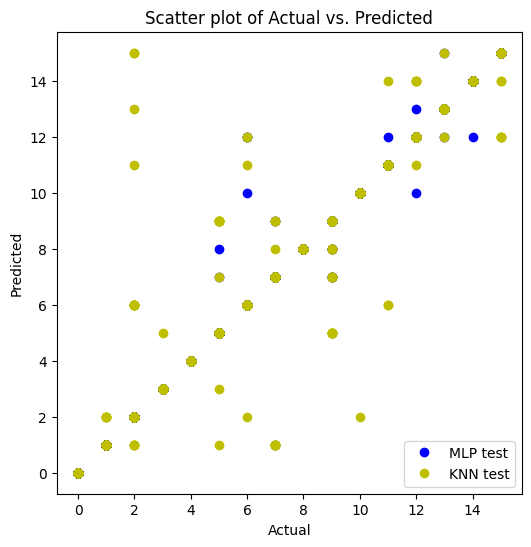

In [21]:
# Plot the raw results
plt.figure(figsize=(6,6))
#plt.plot(y_train, predict_train_mlp, 'ro', label='MLP train')
plt.plot(y_test, predict_test_mlp, 'bo', label='MLP test')

#plt.plot(y_train, predict_train_knn, 'go', label='KNN train')
plt.plot(y_test, predict_test_knn, 'yo', label='KNN test')

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Scatter plot of Actual vs. Predicted')
plt.legend()
plt.show()



Table of Comparsion of Accuracy

In [22]:
import pandas as pd

# initialize data of lists
data = {'Model':['MLP', 'KNN'],
        'Train(%)':[accuracy_train_MLP, accuracy_train_KNN],
        'Test(%)':[accuracy_test_MLP, accuracy_test_KNN],
        'Cross Validation(%)':[cross_val_mlp.mean()*100, cross_val_knn.mean()*100]}

# Create DataFrame
df = pd.DataFrame(data)

# Print the output.
print(df)



  Model   Train(%)    Test(%)  Cross Validation(%)
0   MLP  98.303571  97.291667            86.303836
1   KNN  95.803571  91.354167            95.228960


Bar Graph of Accuracy Comparison

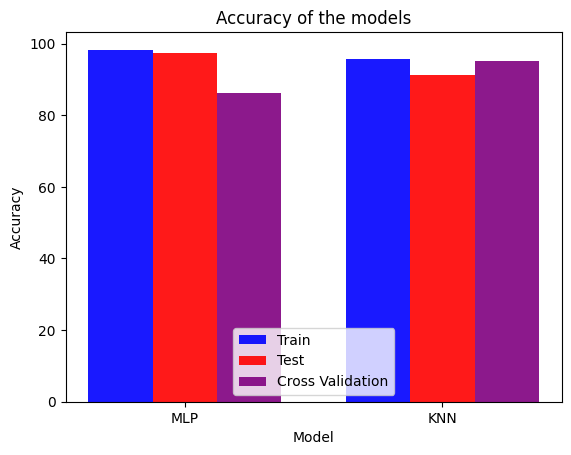

In [23]:
#Bar graph for accuracy
import matplotlib.pyplot as plt
import numpy as np

# data to plot
n_groups = 2
train = (accuracy_train_MLP, accuracy_train_KNN)
test = (accuracy_test_MLP, accuracy_test_KNN)
cross_val = (cross_val_mlp.mean()*100, cross_val_knn.mean()*100)

# create plot
fig, ax = plt.subplots()
index = np.arange(n_groups)
bar_width = 0.25
opacity = 0.9

rects1 = plt.bar(index, train, bar_width,
alpha=opacity,
color='b',
label='Train')

rects2 = plt.bar(index + bar_width, test, bar_width,
alpha=opacity,
color='r',
label='Test')

rects3 = plt.bar(index + bar_width + bar_width, cross_val, bar_width,
alpha=opacity,
color='purple',
label='Cross Validation')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of the models')
plt.xticks(index + bar_width, ('MLP', 'KNN'))
plt.legend()

#plt.tight_layout()
plt.show()

